> # **1. 시계열 데이터란?**  
: 순차적인 시간의 흐름에 따라 수집된 데이터  
- 연속한 관측치 -> 서로 **상관관계** 존재  
- 순서 중요  
<br>

### 단변량 시계열과 다변량 시계열  
**단변량 시계열**  
> 하나의 숫자가 시간에 따라 변하는 것  
- *단일 변수*로 구성  
- 시간의 흐름에 따른 패턴과 트랜드 이해  
**다변량 시계열**  
> 여러 숫자가 동시에 시간에 따라 변하는 것  
- 같은 시간에 기록된 *둘 이상의 변수*로 이루어진 시계열 데이터  
- 변수 간 상호 작용 및 영향력 파악  


## 1.2 시계열 데이터의 특징  
### **1. 시간 의존성**  
- 데이터의 순서 변화 -> 의미 변화  
- 과거의 값이 현재에 영향  
- 시점 간 상관관계 고려해야함  
<br>

### **2. 계절성&추세**  
> = 시간에 따라 장기적으로 증가/감소하는 추세 + 일정 주기로 반복되는 패턴  
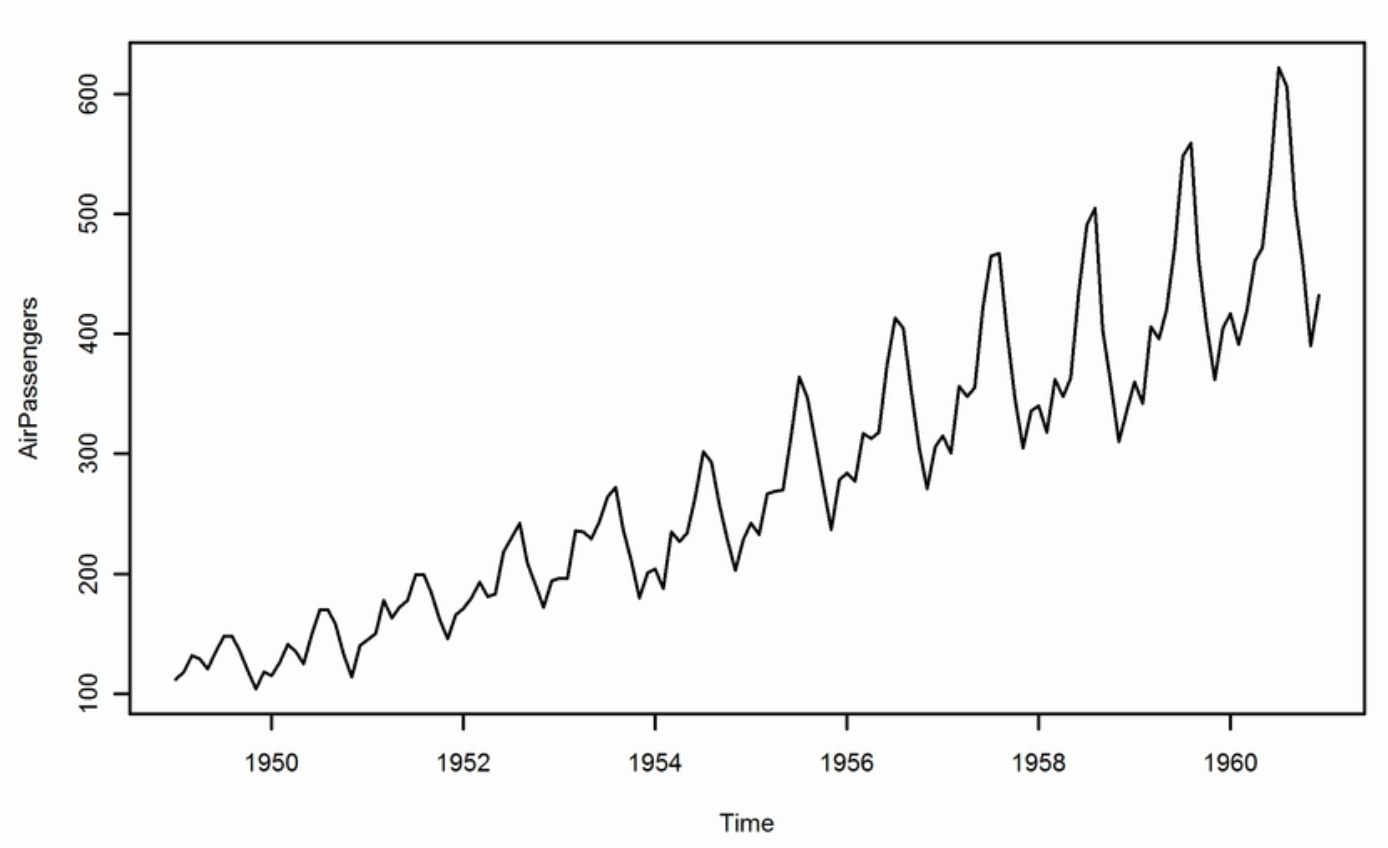  
<br>

### **3. 자기 상관성**  
- 자기자신끼리의 상관관계를 가짐  
- 시간이 지남에 따라 값들 간에 일정한 패턴이나 반복이 존재  
-> *회귀 분석 불가능* (오차항 독립성 가정 위반/ 허위 상관관계 문제)  



## 1.3 시계열 데이터의 분석요인  
1) 추세 요인: 데이터 전반에 걸쳐 시간에 따라 지속적으로 증가/감소하는 경향  
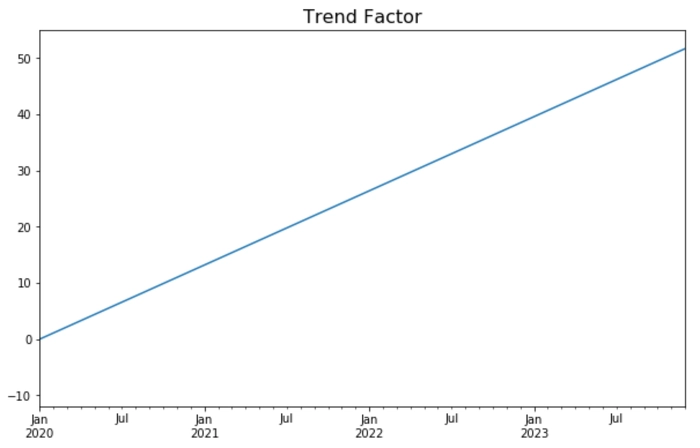  
2) 계절 요인: 일정한 주기(계절, 월, 요일 등 정기적인 주기)로 반복되는 패턴
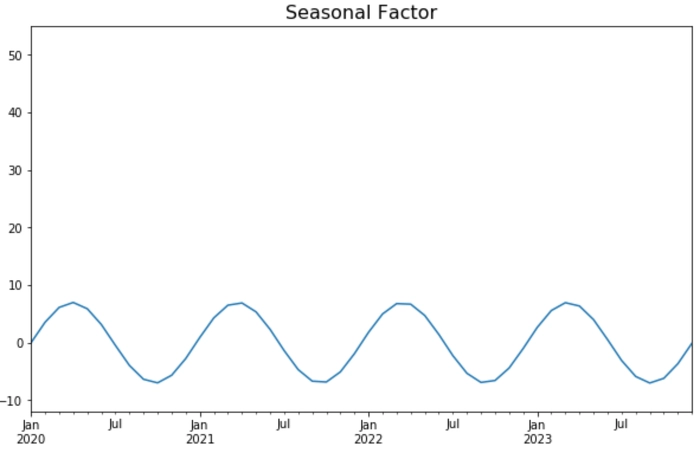  
3) 순환 요인: 계절성보다 더 길고 불규칙한 주기로 반복되는 변동  
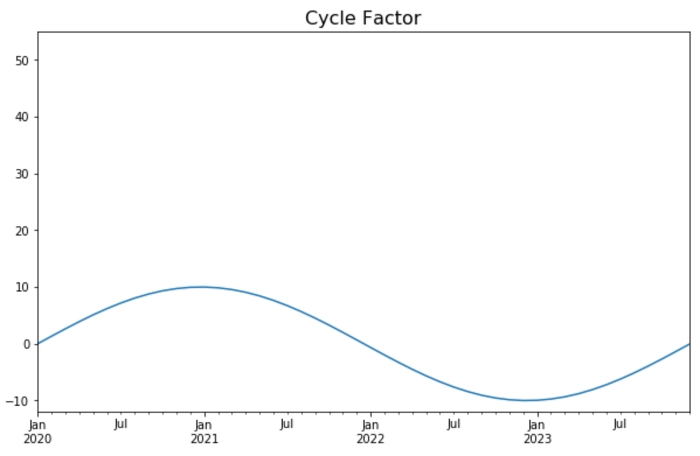  
4) 불규칙 요인: 추세, 계절성, 순환성을 모두 제거한 뒤 남은 예측 불가능한 변동  
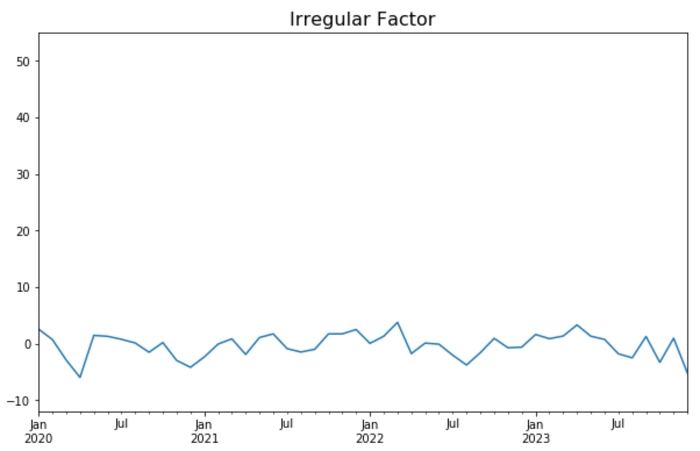

> # **2. 시계열 데이터 전처리**  
시계열의 특성이 왜곡되지 않게 반영하기 위함  
## 2.1 결측치/이상치 탐지 및 처리  
### 결측치 처리  
- 특정 시점의 값 측정되지 않았거나 누락된 상태  
- 센서 오류·수집 누락·전송 지연 등으로 발생  
- 존재 시 *추세/계절성 왜곡* -> 적절한 대치와 보간이 필요  
<br>

### 이상치  
- 값이 측정되었으나, 측정된 값이 일반적이지 않은 경우  
- 측정 오류/ 실제로 특이한 이벤트일 수 있는 극단적 값  
- 단순한 이상한 값이 아니라 신호의 중요한 의미일 가능성 -> 신중한 접근 필요 
이상치 탐지 모델: CART,클러스터링 기반 이상 탐지, 오토 인코더  

## 2.2 EDA  
> 시계열 데이터에서 노이즈를 줄이고, 전체적인 흐름이나 추세를  더 명확하게 파악하기 위해 데이터를 부드럽게 만드는 기술  
### 이동 평균  
> 시계열의 부분집합으로 평균을 구하여 평활화 효과를 얻는 방법  

- 노이즈 제거  
- 추세 파악  
- 예측의 기초자료  
유형: 단순, 가중, 지수  


## 2.3 요소분해  
    = 주어진 시계열 데이터를 개별 성분(추세성, 계절성, 순환성, 불규칙성)으로 분해하는 과정  
### 가법모형  
    = 주어진 시계열 데이터를 개별 성분(추세성, 계절성, 순환성, 불규칙성)으로 분해하는 과정  
- 각 변동 요인들이 독립적으로 더해지며, 모든 요소의 영향 일정  
- 시계열 전체에서 계절성의 진폭이 일정할 때 적합  
<br>

### 승법모형  
    시계열 = 추세 x 계절성 x 불규칙성
- 로그 변환을 통해 만들 수 있음  
- 추세가 커질수록 계절성이나 불규칙성의 효과도 비례해서 커짐  
- 진폭이 시간에 따라 달라질 때에 적합  
<br>

### 분해 방법  
### 1) seasonal_decompose  
    전통적인 시계열 분해 기법, 이동 평균을 통해 추세를 추출한 뒤 잔여 성분에서 계절성을 분리하는 방식  
- 추세 추출 -> Detrending -> 계절성 추정 -> 잔차 산출  
<br>

### 2) STL - LOESS 기반 분해  
    LOESS 사용/ 추세와 계절성이 시간에 따라 변화하는 경우에도 유연하게 포착할 수 있으며, 이상치에 강건한 분해가 가능  
**Inner Loop**  
- 추세 제거 -> Cycle-subseries 추출 후 각 subseries에 LOESS 적용->Low-pass filter로 저주파 성분 제거 -> 계절 성분 확정 -> 계절성 제거 -> LOESS로 추세 갱신 
 
**Outer Loop**  
- 잔차 크기 기준으로 강건성 가중치를 부여해 이상치의 영향력을 줄인 후 Inner Loop 재실행  


> # **3. 정상성 판단**  
    정상성 : 시계열 데이터의 평균, 분산 등 통계적 특성이 시간에 따라 일정한 수준으로 유지되는 것  
- 예측이 가능하다 -> 통계 모델링에 바로 적용하기 좋음  
- 비정상 시계열이면 예측 어려움, 수학적 처리를 거쳐 정상성을 띠도록 변환 후에 분석  

## 3.2 강한 정상성과 약한 정상성  
### 강한 정상성: 완벽하지만 비현실적인 기준  
    시간을 언제로 잡든, 데이터의 확률 분포 자체가 똑같은 상태  
- 모든 통계적 특성이 일정  
- 현실의 데이터는 잡음과 외부 요인 항상 존재 -> 이런 상태 불가능  
<br>

### 약한 정상성: 실무에서 쓰는 현실적인 기준  
- 평균 일정: 시간이 지나도 일정한 수준을 유지  
- 분산 일정: 변동 폭 일정  
- 자기공분산이 시차에만 의존  


## 3.3 정상성 판단  
1) 시각적 판단  
    일정한 기준선(평균)을 중심으로 일정한 폭으로 진동하는 형태를 보임  
- 추세가 뚜렷한 시계열은 차분한 결과로 해석 가능  
2) 통계적 검정의 필요성  
- 그래프만으로는 시각적으로 정상성 여부 판단하기 어려움 
- 단위근이 있는지 확인  
ADF 검정, KPSS 검정 존재  


## 3.4 정상성 확보  
### 1) 추세 제거  
    시계열이 지속적으로 증가하거나 감소할 때 적용   
차분: 연이은 관측값들의 차이를 계산하는 것  
### 2) 계절성 제거  
    시계열이 주기적인 패턴을 가질 때 적용  
- 이후 백색소음과 같은 형태의 데이터로 바뀜  
-> 차분을 통해 완전히 랜덤한 데이터 추출 가능  
### 3) 분산 안정화  
    시계열의 변동 폭이 점점 커지거나 작아질 때 적용  
로그변환: 분산의 정상성 확보하기 위한 방법  


> # **4. 단변량 시계열 분석**
    하나의 변수만을 이용해 시간에 따른 패턴을 분석하고 미래 값을 예측하는 방법  
-> 단변량 시계열은 데이터가 안정적인지 여부에 따라 AR/MA/ARMA 또는 ARIMA/SARIMA로 나뉨  
<br>

## 4.1 안정적 시계열 분석  
    평균, 분산, 자기상관 구조가 시간에 따라 크게 변하지 않는 정상 시계열을 분석하는 방법  
-> 정상성을 만족하는 데이터에는 AR, MA, ARMA 모델을 적용할 수 있음  
<br>

### **1) AR 모델**

    자기회귀 모델로, 과거의 자기 자신 값이 현재 값에 영향을 준다고 보는 모델  

AR(p): 과거 p개 시점의 값을 이용해 현재 값을 예측하는 모델  

- 현재 값은 과거 값들의 선형 조합으로 설명  
- 자기상관성이 존재하는 시계열에 적합  
- 예: 올해 매출은 작년 매출, 재작년 매출의 영향을 받을 수 있음  

수식:  

$$
Y_t = c + \phi_1Y_{t-1} + \phi_2Y_{t-2} + \cdots + \phi_pY_{t-p} + \varepsilon_t
$$

-> AR은 “과거 값이 현재 값을 설명한다”는 구조  
<br>

### **2) MA 모델**

    이동평균 모델로, 과거의 예측 오차가 현재 값에 영향을 준다고 보는 모델  

MA(q): 과거 q개 시점의 오차항을 이용해 현재 값을 예측하는 모델  

- 단순 이동평균 smoothing과 다른 개념  
- 실제 값과 예측 값의 차이인 잔차를 활용  
- 외부 충격이 일정 기간 동안 현재 값에 영향을 준다고 해석 가능  

수식:  

$$
Y_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \cdots + \theta_q\varepsilon_{t-q}
$$

-> MA는 “과거 오차나 충격이 현재 값을 설명한다”는 구조  
<br>

### **3) AR, MA의 전제조건**

    AR과 MA 모델은 정상성, 안정성, 가역성 조건을 고려해야 함  

#### 1) 정상성  

    시계열의 평균, 분산, 자기상관 구조가 시간에 따라 일정해야 함  

- AR 모델은 정상성을 만족해야 안정적으로 사용 가능  
- AR(1)의 경우 보통 계수 조건은 다음과 같음  

$$
|\phi| < 1
$$

- MA 모델은 백색잡음 오차항의 조합이므로 일반적으로 정상성을 만족  

-> 정상성은 시계열 모델이 시간에 따라 안정적으로 작동하기 위한 핵심 조건  
<br>

#### 2) 가역성  

    MA 모델을 관측 가능한 과거 값들의 형태로 다시 표현할 수 있는 조건  

- MA 모델은 오차항을 사용하지만, 오차항은 직접 관측하기 어려움  
- 따라서 오차항을 과거 관측값으로 표현할 수 있어야 함  
- MA 모델에서는 가역성 조건을 확인하는 것이 중요  
- AR 모델은 처음부터 과거 관측값을 사용하므로 가역성 확인이 핵심 조건은 아님  

-> 가역성은 MA 모델의 오차 구조를 안정적으로 해석하기 위한 조건  
<br>

### **4) ARMA 모델**

    AR 모델과 MA 모델을 결합한 안정적 시계열 분석 모델  

ARMA(p, q): 과거 p개의 관측값과 과거 q개의 오차항을 함께 사용하는 모델  

- AR(p): 과거 자기 자신의 값 사용  
- MA(q): 과거 예측 오차 사용  
- 정상성을 만족하는 시계열에 적용 가능  

수식:  

$$
Y_t = c + \phi_1Y_{t-1} + \cdots + \phi_pY_{t-p}
+ \varepsilon_t + \theta_1\varepsilon_{t-1} + \cdots + \theta_q\varepsilon_{t-q}
$$

- ARMA(p, 0) = AR(p)  
- ARMA(0, q) = MA(q)  
- ARMA(0, 0) = 백색잡음  

-> ARMA는 과거 값의 영향과 과거 오차의 영향을 모두 반영하는 모델  
<br>

### **5) 차수 결정 방법: ACF, PACF**

    ACF와 PACF를 통해 AR, MA, ARMA 모델의 차수를 결정할 수 있음  

#### 1) ACF  

    현재 값과 과거 값 사이의 전체 상관관계를 나타내는 함수  

- 간접적인 영향까지 포함  
- MA(q)의 q 차수를 판단할 때 주로 활용  
- ACF가 q+1 시점부터 급격히 0에 가까워지면 MA(q)를 고려  

$$
ACF(k) = Corr(Y_t, Y_{t-k})
$$`

-> ACF는 과거 시점과 현재 시점 사이의 전체적인 상관성을 보여줌  
<br>

#### 2) PACF  

    중간 시점들의 영향을 제거한 순수한 직접 상관관계를 나타내는 함수  

- 직접적인 영향만 확인  
- AR(p)의 p 차수를 판단할 때 주로 활용  
- PACF가 p+1 시점부터 급격히 0에 가까워지면 AR(p)를 고려  

-> PACF는 특정 과거 시점이 현재에 직접 미치는 영향을 보여줌  
<br>

#### 3) ACF, PACF 해석 기준  
ACF와 PACF는 차수를 정하는 1차 기준이고, 최종적으로는 AIC, BIC 등을 함께 고려  
<br>

## 4.2 불안정 시계열 분석  
    추세, 계절성, 분산 변화 등으로 인해 정상성을 만족하지 않는 시계열을 분석하는 방법  
-> 불안정 시계열은 차분이나 계절 차분을 통해 정상성을 확보한 뒤 분석  
<br>

### **1) ARIMA 모델**

    ARMA 모델에 차분 과정을 추가한 비정상 시계열 분석 모델  

ARIMA(p, d, q): AR, 차분, MA를 결합한 모델  

- p: AR 차수  
- d: 차분 횟수  
- q: MA 차수  

$$
ARIMA(p,d,q) = AR(p) + I(d) + MA(q)
$$

- d = 0이면 ARMA와 동일함  
- d = 1이면 1차 차분을 통해 추세를 제거함  
- 비정상 시계열을 정상 시계열로 바꾼 뒤 ARMA 구조를 적용함  

차분:  

$$
Y'_t = Y_t - Y_{t-1}
$$

-> ARIMA는 추세가 있는 데이터를 차분한 뒤 ARMA로 분석하는 모델  
<br>

### **2) SARIMA 모델**

    ARIMA 모델에 계절성 구조를 추가한 모델  

SARIMA(p, d, q)(P, D, Q)m: 비계절 요소와 계절 요소를 함께 반영하는 모델  

- p, d, q: 비계절 ARIMA 파라미터  
- P, D, Q: 계절 ARIMA 파라미터  
- m: 계절 주기의 길이  

- 비계절 차분 d = 1  
- 계절 차분 D = 1  
- 계절 주기 m = 12  
- 월별 데이터에서 12개월마다 반복되는 패턴을 반영할 수 있음  

계절 차분:  

$$
Y^*_t = Y_t - Y_{t-m}
$$

-> SARIMA는 추세와 계절성을 모두 가진 시계열을 분석할 때 적합  
<br>

## 5. 다변량 시계열 분석  
    여러 개의 변수가 시간에 따라 서로 영향을 주고받는 구조를 분석하는 방법  
-> 하나의 변수만 보는 단변량 분석과 달리, 변수 간 상호작용을 함께 고려함  
<br>

### **1) VAR 모델**

    여러 변수의 과거 값이 각 변수의 현재 값에 영향을 준다고 보는 모델  

VAR(Vector Autoregression): 다변량 자기회귀 모델  

- 자기 자신의 과거 값뿐만 아니라 다른 변수의 과거 값도 함께 사용  
- 경제, 금융, 수요 예측처럼 변수 간 상호작용이 중요한 경우에 사용  
- 모든 변수를 종속변수처럼 취급  

- X는 자신의 과거 값과 Y의 과거 값으로 예측  
- Y도 자신의 과거 값과 X의 과거 값으로 예측  

-> VAR은 여러 변수가 서로 영향을 주고받는 시계열 구조를 분석하는 모델  
<br>

### **2) VAR의 활용**

    VAR은 단순 예측뿐만 아니라 변수 간 영향 관계 분석에도 활용됨  

#### 1) Granger 인과관계 검정  

    한 변수의 과거 정보가 다른 변수의 미래 예측에 도움이 되는지 확인하는 방법  

- 예측에 도움이 되는 시간적 선후관계를 의미  
- p-value가 작으면 해당 변수를 VAR 모델에 포함하는 것을 고려할 수 있음  

-> Granger 인과관계는 “예측에 도움이 되는가”를 판단하는 검정  
<br>

#### 2) 충격반응함수  

    한 변수에 발생한 충격이 다른 변수에 시간에 따라 어떤 영향을 주는지 분석  

- 예: 금리 충격이 소비, 투자, 물가에 미치는 영향 분석  
- 충격의 방향과 지속 기간을 확인할 수 있음  

-> 충격반응함수는 변수 간 동적 영향을 해석하는 데 사용됨  
<br>

#### 3) 예측오차 분산분해  

    예측 오차가 어떤 변수의 충격에서 비롯되었는지 비율로 분석  

- 특정 변수의 예측 오차 중 다른 변수의 영향이 얼마나 큰지 확인  
- 변수 간 중요도를 해석하는 데 활용  

-> 분산분해는 예측 오차의 원인을 변수별로 나누어 보는 방법  
<br>

## 6. 딥러닝을 활용한 시계열 분석  
    딥러닝 모델을 활용해 복잡한 비선형 패턴과 장기 의존성을 학습하는 방법  
-> 데이터가 많고 패턴이 복잡할수록 딥러닝 기반 시계열 분석이 효과적일 수 있음  
<br>

### **1) RNN 계열**

    이전 시점의 정보를 현재 시점으로 전달하는 순환 구조의 신경망  

RNN(Recurrent Neural Network): 순차 데이터 처리에 적합한 기본 딥러닝 모델  

- 과거 정보를 은닉 상태에 저장  
- 짧은 시계열 패턴 분석에 적합  
- 긴 시계열에서는 장기 의존성 학습이 어려움  

-> RNN은 순서가 중요한 시계열 데이터를 처리하는 기본 모델  
<br>

### **2) LSTM과 GRU**

    RNN의 장기 의존성 문제를 개선한 모델  

#### 1) LSTM  

    게이트 구조를 통해 중요한 정보를 오래 기억할 수 있도록 만든 모델  

- 장기 의존성 학습에 강함  
- 구조가 복잡하고 학습 시간이 오래 걸림  
- 긴 시계열 예측에 적합  

#### 2) GRU  

    LSTM을 단순화한 모델  

- LSTM보다 빠르게 학습 가능  
- 비교적 적은 데이터에서도 활용 가능  
- LSTM보다 구조가 단순함  

-> LSTM과 GRU는 RNN보다 긴 과거 정보를 더 잘 반영할 수 있음  
<br>

### **3) Transformer 계열**

    Attention 구조를 활용해 시계열의 중요한 시점 정보를 학습하는 모델  

Transformer 기반 시계열 모델은 긴 시계열과 복잡한 패턴 학습에 강함  

- RNN보다 병렬 처리가 효율적  
- 장기 의존성을 잘 포착  
- 데이터가 충분히 많을 때 높은 성능을 낼 수 있음  

#### 1) Informer  

    긴 시계열 예측에 특화된 Transformer 기반 모델  

- 계산량을 줄여 긴 시계열 처리에 적합  
- 전력 수요, 교통량 예측 등에 활용 가능  

#### 2) Autoformer  

    추세와 계절성을 분해하는 구조를 반영한 모델  

- 주기성이 뚜렷한 데이터에 적합  
- 월별 판매량, 계절 수요 예측 등에 활용 가능  

#### 3) TFT  

    다양한 외생 변수를 함께 반영할 수 있는 Transformer 기반 모델  

- 날씨, 휴일, 이벤트 등 외부 변수를 함께 사용할 수 있음  
- 변수 중요도를 해석할 수 있어 실무 활용도가 높음  

-> Transformer 계열은 긴 시계열, 복잡한 패턴, 외생 변수가 많은 문제에 적합  
<br>

### **4) Foundation Model**

    대규모 시계열 데이터로 사전학습된 범용 시계열 모델  

Foundation Model은 특정 데이터에만 맞춘 모델이 아니라 다양한 시계열 문제에 적용 가능한 모델  

- 대규모 데이터로 사전학습  
- 새로운 데이터에 빠르게 적용 가능  
- Fine-tuning 또는 Prompting 방식으로 활용 가능  

예시 모델:  

- TimeGPT  
- TimesFM  
- Chronos  
- Moirai  

활용 방식:  

- Without Adaptation: 별도 학습 없이 프롬프트나 입력 형식만 조정  
- Adapt LLM: LLM이나 foundation model을 시계열 데이터에 맞게 fine-tuning  
- Adapt to LLM: 숫자 시계열을 텍스트 설명으로 바꾸어 LLM에 입력  

-> Foundation Model은 범용성과 빠른 적용성이 강점인 최신 시계열 분석 방법  
<br>

### **5) 모델 선택 기준**

    데이터의 크기, 길이, 계절성, 변수 개수, 해석 가능성에 따라 적절한 모델을 선택  
-> 통계 모델은 해석력이 좋고, 딥러닝 모델은 복잡한 패턴 학습에 강함  
<br>